In [23]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.transforms.functional import normalize

In [39]:
im_path = "/data/datasets/nii/MSD/Task01_BrainTumour/imagesTr/BRATS_002.nii.gz"
gt_path = "/data/datasets/nii/MSD/Task01_BrainTumour/labelsTr/BRATS_002.nii.gz"
im = nib.load(im_path).get_fdata()
gt = nib.load(gt_path).get_fdata()

In [40]:
im = im [..., 2]
im = torch.Tensor(im)
im = im.permute(2,0,1).unsqueeze(1).repeat(1,3,1,1)
im = normalize(im, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
im = im.permute(0, 2, 3, 1)
im = (im - im.min()) / (im.max() - im.min())

In [41]:
im.shape

torch.Size([155, 240, 240, 3])

In [42]:
np.unique(gt)

array([0., 1., 2., 3.])

In [43]:
gt[gt != 1] = 0
gt[gt == 1] = 1

In [44]:
np.argwhere(gt.sum(axis=(0, 1))).squeeze()

array([ 67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127])

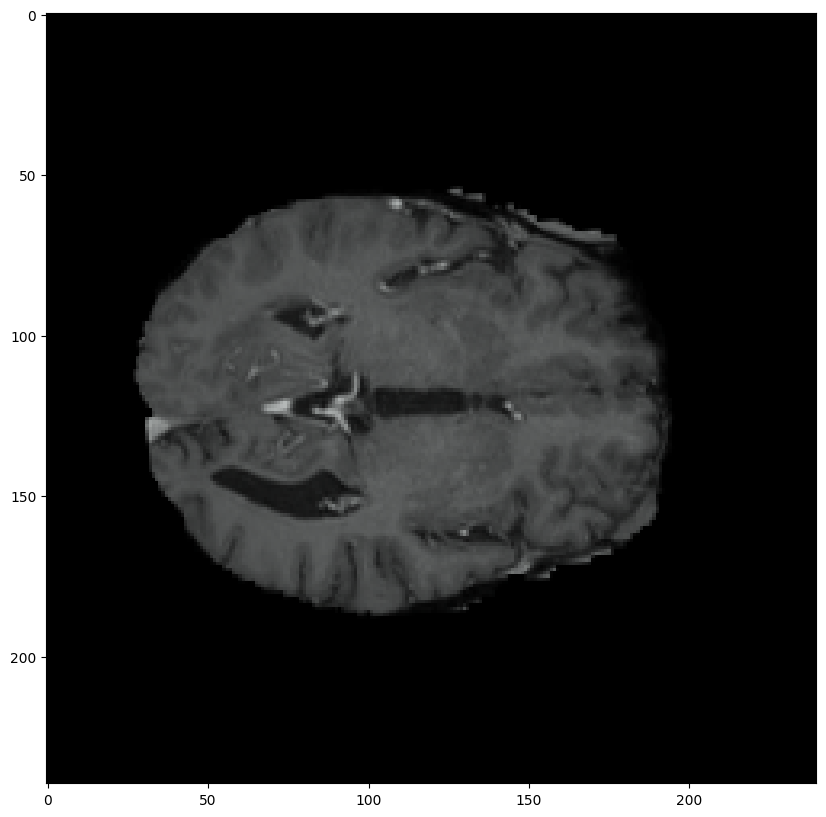

In [48]:
plt.figure(figsize=(10,10))
plt.imshow(im[70], cmap="grey")
# plt.imshow(gt[:, :, 70], alpha=0.4, cmap="jet")